## <small>
Copyright (c) 2017-21 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning: A Visual Approach
## by Andrew Glassner, https://glassner.com
### Order: https://nostarch.com/deep-learning-visual-approach
### GitHub: https://github.com/blueberrymusic
------

### What's in this notebook

This notebook is provided as a “behind-the-scenes” look at code used to make some of the figures in this chapter. It is cleaned up a bit from the original code that I hacked together, and is only lightly commented. I wrote the code to be easy to interpret and understand, even for those who are new to Python. I tried never to be clever or even more efficient at the cost of being harder to understand. The code is in Python3, using the versions of libraries as of April 2021.

This notebook may contain additional code to create models and images not in the book. That material is included here to demonstrate additional techniques.

Note that I've included the output cells in this saved notebook, but Jupyter doesn't save the variables or data that were used to generate them. To recreate any cell's output, evaluate all the cells from the start up to that cell. A convenient way to experiment is to first choose "Restart & Run All" from the Kernel menu, so that everything's been defined and is up to date. Then you can experiment using the variables, data, functions, and other stuff defined in this notebook.

## Chapter 22: GANs - Notebook 2: Gaussian GAN

2D Gaussian GAN adapted from https://github.com/EmilienDupont/generative-adversarial-network/blob/master/generative_adversarial_network.py

In [23]:
from keras.layers import Activation, Dense, Input, LeakyReLU
from keras.models import Model
from keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [24]:
# Workaround for Keras issues on Mac computers (you can comment this
# out if you're not on a Mac, or not having problems)
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [25]:
# Make a File_Helper for saving and loading files.

save_files = False  # set True if you actually want to write files

try:
    import os, sys, inspect

    current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
    sys.path.insert(0, os.path.dirname(current_dir))  # path to parent dir

    from DLBasics_Utilities import File_Helper
    print("Using real DLBasics_Utilities.File_Helper")

except ModuleNotFoundError:
    import os

    class File_Helper:
        def __init__(self, save_files=False):
            self.save_files = save_files
            self.INPUT_DIR = os.getcwd()

        def get_input_data_dir(self):
            d = self.INPUT_DIR
            print(f"get_input_data_dir (stub) -> {d}")
            return d

        def get_input_file_path(self, filename):
            path = os.path.join(self.INPUT_DIR, filename)
            print(f"get_input_file_path (stub) -> {path}")
            return path

        def save_figure(self, fig, filename, *args, **kwargs):
            import matplotlib.pyplot as plt
            if self.save_files and filename:
                fig.savefig(filename, *args, **kwargs)
                print(f"save_figure (stub) – saved figure to '{filename}'")
            else:
                print(f"save_figure (stub) – would save '{filename}', but skipping.")

        def load_model_weights(self, model, weights_filename):
            print(f"load_model_weights (stub) – no real weights file '{weights_filename}', returning False.")
            return False

        def save_model_weights(self, model, weights_filename):
            if self.save_files:
                model.save_weights(weights_filename)
                print(f"save_model_weights (stub) – saved weights to '{weights_filename}'")
            else:
                print(f"save_model_weights (stub) – would save '{weights_filename}', but skipping.")

        def __repr__(self):
            return f"<Stub File_Helper save_files={self.save_files}, INPUT_DIR='{self.INPUT_DIR}'>"

    print("Using stub File_Helper (DLBasics_Utilities not found)")

file_helper = File_Helper(save_files)
file_helper

Using stub File_Helper (DLBasics_Utilities not found)


<Stub File_Helper save_files=False, INPUT_DIR='/content'>

In [26]:
data_dimensions = 2
noise_dimensions = 4
random_seed = 42

# Training parameters
batch_size = 32
number_of_examples = 10000
number_of_batches = int(number_of_examples / batch_size)

In [27]:
def make_generator(dense_list):
    generator_input = Input(shape=(noise_dimensions,))
    generator_dense_layers = []
    generator_activation_layers = []
    for i in range(len(dense_list)):
        if i==0:
            generator_dense_layers.append(Dense(dense_list[i])(generator_input))
        else:
            generator_dense_layers.append(Dense(dense_list[i])(generator_activation_layers[i-1]))
        generator_activation_layers.append(LeakyReLU(0.1)(generator_dense_layers[i]))

    generator_output = Dense(data_dimensions)(generator_activation_layers[len(dense_list)-1])

    generator = Model(inputs=generator_input, outputs=generator_output)
    # Generator loss does not matter, as generator will only be trained through GAN
    generator.compile(loss='mse', optimizer='adam')
    return generator

In [28]:
def make_discriminator(dense_list):
    discriminator_input = Input(shape=(data_dimensions,))
    discriminator_dense_layers = []
    discriminator_activation_layers = []
    for i in range(len(dense_list)):
        if i==0:
            discriminator_dense_layers.append(Dense(dense_list[i])(discriminator_input))
        else:
            discriminator_dense_layers.append(Dense(dense_list[i])(discriminator_activation_layers[i-1]))
        discriminator_activation_layers.append(LeakyReLU(0.1)(discriminator_dense_layers[i]))

    discriminator_output = Dense(1, activation='sigmoid')(discriminator_activation_layers[len(dense_list)-1])

    discriminator = Model(inputs=discriminator_input, outputs=discriminator_output)
    discriminator.compile(loss='binary_crossentropy', optimizer='adam')
    return (discriminator)

In [29]:
def make_gan(generator, discriminator):
    # The 'trainable" stuff is a bit subtle. To apply it to a model, we set it
    # for the model and then compile it. The result is that when we manipulate
    # that model (e.g., fitting it), the layers in the model will not update. But
    # if those layers are shared with other models, and their 'trainable' flag
    # was left to True, then they WILL update when we use those models. So the
    # 'trainable' flag for a model might better be named 'trainable_within_this_model'.
    # Here, we build the GAN so that when it runs, the generator learns, but the
    # discriminator does not. This is because the generator needs to use the output
    # of the discriminator, so we lock it down when the generator is learning.
    # Then we update the discriminator in its own step, using a 'trainable=True' model.
    discriminator.trainable = False
    gan_input = Input(shape=(noise_dimensions,))
    gan_layer = generator(gan_input)
    gan_output = discriminator(gan_layer)
    gan = Model(inputs=gan_input, outputs=gan_output)
    gan.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=2e-4))
    discriminator.trainable = True
    return(gan)

In [30]:
# The real data we're comparing to
def get_real_data():
    real_data = np.random.normal(5, 1, (number_of_examples, data_dimensions))
    return real_data

In [31]:
def get_batch_of_normal_noise(mean=0, std=1, shape=(batch_size, noise_dimensions)):
    return np.random.normal(mean, std, shape)

In [32]:
def train_discriminator(discriminator, batch_of_data, label):
    if label == 0:
        labels = np.zeros(batch_size).astype(int)
    else:
        labels = np.ones(batch_size).astype(int)
    discriminator_loss = discriminator.train_on_batch(batch_of_data, labels)
    return discriminator_loss

In [33]:
def train_generator(gan):
    noise_batch = get_batch_of_normal_noise()
    labels = np.ones(batch_size).astype(int)
    gan_loss = gan.train_on_batch(noise_batch, labels)
    return gan_loss

In [34]:
def pre_train_discriminator(discriminator, generator, real_data):
    shuffled_data = np.random.permutation(real_data)
    for batch in range(number_of_batches):
        # first train on a batch of real data
        batch_of_data = shuffled_data[batch * batch_size: (batch + 1) * batch_size]
        train_discriminator(discriminator, batch_of_data, 1)
        # now train on a batch of fake data
        noise_batch = get_batch_of_normal_noise()
        batch_of_data = generator.predict(noise_batch)
        train_discriminator(discriminator, batch_of_data, 0)

In [35]:
def train_gan_one_epoch(gan, generator, discriminator, real_data):
    shuffled_data = np.random.permutation(real_data)
    for batch in range(number_of_batches):
        # discriminator with real data
        batch_of_data = shuffled_data[batch * batch_size: (batch + 1) * batch_size]
        train_discriminator(discriminator, batch_of_data, 1)
        # generator
        gan_loss = train_generator(gan)
        # disriminator with fake data
        noise_batch = get_batch_of_normal_noise()
        batch_of_data = generator.predict(noise_batch)
        discriminator_loss = train_discriminator(discriminator, batch_of_data, 0)
        # generator
        gan_loss = train_generator(gan)
    return((gan_loss, discriminator_loss))

In [36]:
def plot_fake_and_real_data(fig, data, generator, num_points=256):
    ax = fig.gca()
    ax.axis('equal')

    noise_batch = get_batch_of_normal_noise(shape=(num_points, noise_dimensions))
    fake_data_batch = generator.predict(noise_batch)
    data_batch = data[np.random.randint(number_of_examples, size=num_points)]

    fake_mean_x = np.mean(fake_data_batch[:,0])
    fake_mean_y = np.mean(fake_data_batch[:,1])
    fake_std_x = np.std(fake_data_batch[:,0])
    fake_std_y = np.std(fake_data_batch[:,1])

    mean_x = np.mean(data_batch[:,0])
    mean_y = np.mean(data_batch[:,1])
    std_x = np.std(data_batch[:,0])
    std_y = np.std(data_batch[:,1])

    blue_color = '#2578c7'
    orange_color = '#fca429'

    c = patches.Ellipse((mean_x, mean_y), 2*std_x, 2*std_y, \
                        edgecolor=blue_color, fill=False, linewidth=5)
    ax.add_patch(c)
    c = patches.Ellipse((mean_x, mean_y), 2*std_x, 2*std_y, \
                        edgecolor='black', fill=False, linewidth=1)
    ax.add_patch(c)
    c = patches.Ellipse((fake_mean_x, fake_mean_y), 2*fake_std_x, 2*fake_std_y, \
                        edgecolor=orange_color, fill=False, linewidth=5)
    ax.add_patch(c)
    c = patches.Ellipse((fake_mean_x, fake_mean_y), 2*fake_std_x, 2*fake_std_y, \
                        edgecolor='black', fill=False, linewidth=1)
    ax.add_patch(c)

    ax.scatter(fake_data_batch[:,0],fake_data_batch[:,1], edgecolor='None', c=orange_color, alpha=0.3)
    ax.scatter(data_batch[:,0], data_batch[:,1], edgecolor='None', c=blue_color, alpha=0.3)

In [37]:
def get_models():
    generator = make_generator((16,))
    discriminator = make_discriminator((16,16))
    gan = make_gan(generator, discriminator)
    return (generator, discriminator, gan)

In [38]:
def train_gan():
    history = []
    rows = 3
    columns = 4
    number_of_epochs = 21
    plot_epochs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13]
    plot_number = 0

    np.random.seed(random_seed)
    real_data = get_real_data()
    (generator, discriminator, gan) = get_models()
    pre_train_discriminator(discriminator, generator, real_data)

    fig = plt.figure(figsize=(10, 8))
    for epoch in range(number_of_epochs):
        train_data = train_gan_one_epoch(gan, generator, discriminator, real_data)
        history.append(train_data)
        if epoch in plot_epochs:
            plt.subplot(rows, columns, plot_number+1)
            plot_fake_and_real_data(fig, real_data, generator)
            ax = fig.gca()
            ax.set_xlim(-1, 14)
            ax.set_ylim(-1, 16)
            plt.title('Epoch '+str(epoch))
            plot_number += 1
    plt.tight_layout()
    file_helper.save_figure('GAN-2D-learn-plots')
    plt.show()
    return np.array(history)

In [39]:
def draw_loss_plots(history):
    plt.clf()
    fig = plt.figure(figsize=(8,6))
    plt.plot(history[:,0], c='#008800', linewidth=2, label='generator loss')
    plt.plot(history[:,1], c='#aa00aa', linewidth=2, label='discriminator loss')
    ax = plt.gca()
    ax.legend(loc='upper right', shadow=True)
    file_helper.save_figure('GAN-2D-learn-history')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

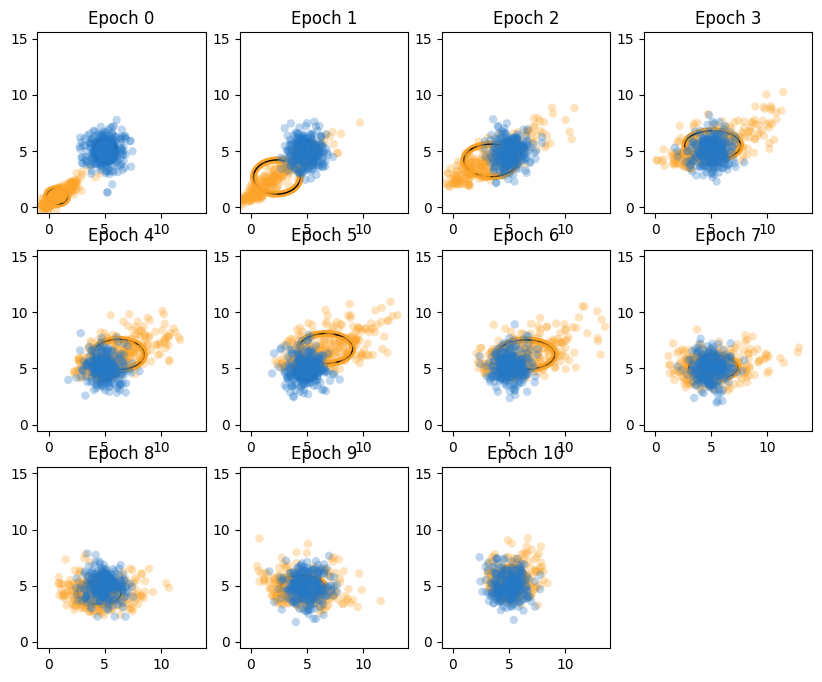

In [41]:
history = train_gan()
draw_loss_plots(history)